In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Data
X, y = make_regression(n_samples=5000, n_features=20, random_state=42)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2)

# Architectures and Wrappers

## Network Architecture and Training Functions

In [7]:
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.nn.utils import clip_grad_norm_
import torch

class MLPRegressor(nn.Module):
    def __init__(self, input_size:int, hidden_size:int, n_hidden:int,  output_size:int):
        super(MLPRegressor, self).__init__()

        self.input_layer = nn.Linear(input_size, hidden_size)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_size, output_size)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.relu(layer(x))

        x = self.output_layer(x)

        return x


## Regressor Ensemble Wrapper

In [21]:
import copy
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.utils.validation import check_is_fitted
import torch
from torch import nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Subset, TensorDataset


class RegressionEnsembleWrapper(RegressorMixin, BaseEstimator):

    def __init__(
        self,
        models: list = None,
        batch_size: int = 256,
        lr: float = 3e-4,
        epochs: int = 30,
        device: str = None,
    ):
        """Initializes the regression ensemble wrapper with base neural network models."""
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        self.models = models if models is not None else []
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray):
        """Fit all the base estimators on the training data using K-Fold CV."""

        def _get_train_loaders(
            dataset: TensorDataset, train_idx, val_idx, batch_size: int = 256
        ):
            train_loader = DataLoader(
                Subset(dataset, train_idx), batch_size=batch_size, shuffle=True
            )
            val_loader = DataLoader(
                Subset(dataset, val_idx), batch_size=batch_size, shuffle=False
            )
            return train_loader, val_loader

        def _train_one_epoch(
            model, loader, optimizer, criterion, device, max_norm: float = 1.0
        ):
            model.train()
            running_loss = 0.0
            for batch_X, batch_y in loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(batch_X), batch_y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            return running_loss / len(loader)

        def _calculate_val_loss(model, loader, criterion, device):
            model.eval()
            running_loss = 0.0
            with torch.no_grad():
                for batch_X, batch_y in loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    output = model(batch_X)
                    loss = criterion(output, batch_y)
                    running_loss += loss.item()
            return running_loss / len(loader)

        # FIX: Explicitly parse targets to match MSELoss expected shapes
        y_tensor = (
            torch.Tensor(y).float().unsqueeze(1)
            if y.ndim == 1
            else torch.Tensor(y).float()
        )
        trainval_set = TensorDataset(torch.Tensor(X).float(), y_tensor)

        kf = KFold(n_splits=len(self.models), shuffle=True, random_state=42)
        fitted_models = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            print(
                f"\n ===================== Training Fold {fold}  ===================== \n"
            )

            train_loader, val_loader = _get_train_loaders(
                dataset=trainval_set,
                train_idx=train_idx,
                val_idx=val_idx,
                batch_size=self.batch_size,
            )

            # Move individual fold model to target device
            model = copy.deepcopy(self.models[fold]).to(self.device)
            optimizer = torch.optim.Adam(model.parameters(), lr=self.lr)
            criterion = torch.nn.MSELoss()

            # FIX: Initialize fold-specific metrics & weights tracking
            best_val_loss = float("inf")
            best_model_wts = copy.deepcopy(model.state_dict())

            for epoch in range(self.epochs):
                train_loss = _train_one_epoch(
                    model, train_loader, optimizer, criterion, self.device
                )
                val_loss = _calculate_val_loss(
                    model, val_loader, criterion, self.device
                )

                # FIX: Capture the exact state dict weights configuration of the best epoch
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model_wts = copy.deepcopy(model.state_dict())

                if (epoch + 1) % 10 == 0 or epoch == 0:
                    print(
                        f"Epoch {epoch+1:02d}/{self.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
                    )

            # Load the optimal epoch weights back to the model before saving
            model.load_state_dict(best_model_wts)
            fitted_models.append(model)

        self.models = fitted_models
        self.is_fitted_ = True  # Scikit-learn flag convention (ends with trailing underscore)

        return self

    def _mean_response(self, X: np.ndarray) -> np.ndarray:
        """Internal helper for soft voting / averaging regression values across estimators."""
        # Convert NumPy inputs safely to PyTorch evaluation syntax
        X_tensor = torch.Tensor(X).float().to(self.device)
        pred = np.zeros((len(self.models), len(X)))

        for idx, model in enumerate(self.models):
            model.eval()
            with torch.no_grad():
                # Extract output out of tensor context back to clean numpy
                predictions = model(X_tensor).cpu().numpy().flatten()
                pred[idx] = predictions

        return pred.mean(axis=0)

    def predict(self, X: np.ndarray) -> np.ndarray:
        check_is_fitted(self, attributes=["is_fitted_"])
        return self._mean_response(X)

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """Returns the R^2 determination score on the given test data and labels."""
        check_is_fitted(self, attributes=["is_fitted_"])
        pred = self.predict(X)
        return r2_score(y, pred)  # Correct sequence order: (y_true, y_pred)

# Model Training

In [22]:
from sklearn.preprocessing import StandardScaler

model_parameters = {
    'input_size':  X_train_val.shape[1],
    'hidden_size': 64,    # neurons per layer
    'n_hidden':    2,     # number of layers
    'output_size': 1
}

models = []
for i in range(5):
    m = MLPRegressor(**model_parameters)
    models.append(m)



# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_val)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_val.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()


regressor = RegressionEnsembleWrapper(
    models=models,
    lr=1e-3,
    epochs=100,
    batch_size=64
)
regressor.fit(X_train_scaled, y_train_scaled)


 ===================== Training Fold 0  ===================== 

Epoch 01/100 | Train Loss: 0.5132 | Val Loss: 0.0849
Epoch 10/100 | Train Loss: 0.0036 | Val Loss: 0.0048
Epoch 20/100 | Train Loss: 0.0016 | Val Loss: 0.0032
Epoch 30/100 | Train Loss: 0.0010 | Val Loss: 0.0024
Epoch 40/100 | Train Loss: 0.0007 | Val Loss: 0.0023
Epoch 50/100 | Train Loss: 0.0005 | Val Loss: 0.0018
Epoch 60/100 | Train Loss: 0.0003 | Val Loss: 0.0015
Epoch 70/100 | Train Loss: 0.0003 | Val Loss: 0.0017
Epoch 80/100 | Train Loss: 0.0002 | Val Loss: 0.0013
Epoch 90/100 | Train Loss: 0.0002 | Val Loss: 0.0012
Epoch 100/100 | Train Loss: 0.0002 | Val Loss: 0.0011

 ===================== Training Fold 1  ===================== 

Epoch 01/100 | Train Loss: 0.5695 | Val Loss: 0.0926
Epoch 10/100 | Train Loss: 0.0032 | Val Loss: 0.0047
Epoch 20/100 | Train Loss: 0.0014 | Val Loss: 0.0028
Epoch 30/100 | Train Loss: 0.0008 | Val Loss: 0.0020
Epoch 40/100 | Train Loss: 0.0006 | Val Loss: 0.0016
Epoch 50/100 | Train 

RegressionEnsembleWrapper(batch_size=64, device=device(type='cpu'), epochs=100,
                          lr=0.001,
                          models=[MLPRegressor(
  (input_layer): Linear(in_features=20, out_features=64, bias=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
),
                                  MLPRegressor(
  (input_...
    (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
),
                                  MLPRegressor(
  (input_layer): Linear(in_features=20, out_features=64, bias=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)])

# Feature Importance and Patrial Dependency Plots

## Permutaion


--- Zbiór Treningowy ---
Cecha 0: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 1: Mean=0.0033, CI=[0.0033, 0.0033]
Cecha 2: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 3: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 4: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 5: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 6: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 7: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 8: Mean=0.0003, CI=[0.0003, 0.0003]
Cecha 9: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 10: Mean=0.0003, CI=[0.0002, 0.0003]
Cecha 11: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 12: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 13: Mean=0.0012, CI=[0.0012, 0.0013]
Cecha 14: Mean=0.0017, CI=[0.0017, 0.0017]
Cecha 15: Mean=0.0001, CI=[0.0001, 0.0001]
Cecha 16: Mean=0.0030, CI=[0.0029, 0.0030]
Cecha 17: Mean=0.0022, CI=[0.0021, 0.0022]
Cecha 18: Mean=0.0000, CI=[0.0000, 0.0000]
Cecha 19: Mean=0.0005, CI=[0.0005, 0.0005]

--- Zbiór Testowy ---
Cecha 0: Mean=-0.0000, CI=[-0.0000, -0.0000]
Cecha 1: Mean=0.5564, CI=[0.5532, 0.5595]
Cecha 2: Mean=

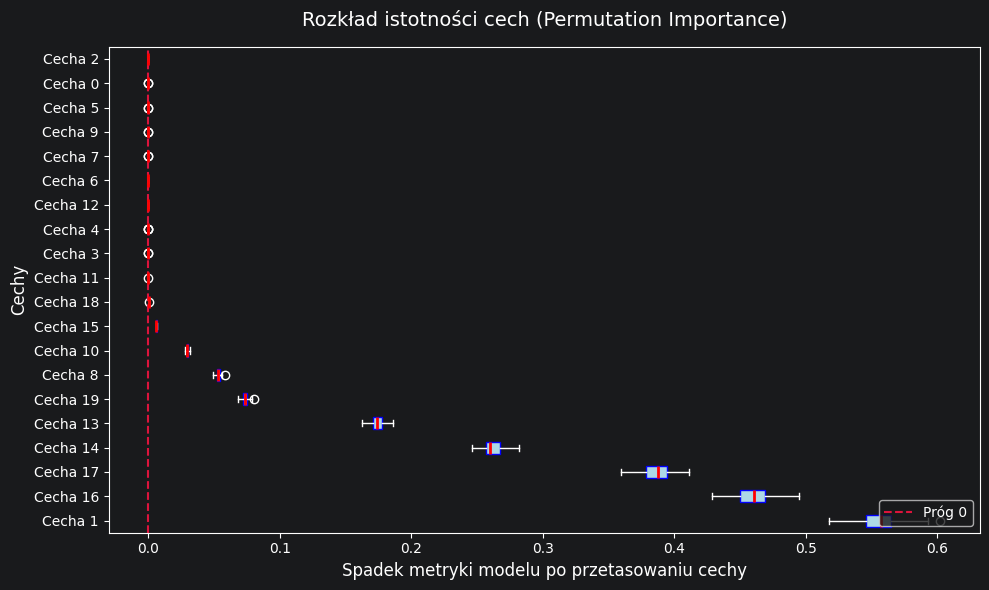

In [29]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

for name, X_data, y_data in [('Treningowy', X_train_val, y_train_val), ('Testowy', X_test_scaled, y_test_scaled)]:
    result = permutation_importance(regressor, X_data, y_data, n_repeats=100, random_state=0, scoring='r2')

    print(f"\n--- Zbiór {name} ---")
    significant_features = []

    for i in range(X_data.shape[1]):
        mean = result.importances_mean[i]
        std = result.importances_std[i]

        # Wyznaczenie 95% przedziału ufności dla średniej
        margin_of_error = 1.96 * (std / np.sqrt(100))
        ci_lower = mean - margin_of_error
        ci_upper = mean + margin_of_error

        if ci_upper < 0 or ci_lower > 0:
            significant_features.append((i, mean, ci_lower, ci_upper))
            print(f"Cecha {i}: Mean={mean:.4f}, CI=[{ci_lower:.4f}, {ci_upper:.4f}]")



feature_names = (
    X_test.columns
    if hasattr(X_test, "columns")
    else [f"Cecha {i}" for i in range(X_test.shape[1])]
)


sorted_importances_idx = result.importances_mean.argsort()[::-1]
sorted_feature_names = [feature_names[i] for i in sorted_importances_idx]
sorted_importances = result.importances[sorted_importances_idx]

plt.figure(figsize=(10, 6))

plt.boxplot(
    sorted_importances.T,
    vert=False,
    tick_labels=sorted_feature_names,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
)

plt.axvline(x=0, color="crimson", linestyle="--", linewidth=1.5, label="Próg 0")

plt.title("Rozkład istotności cech (Permutation Importance)", fontsize=14, pad=15)
plt.xlabel("Spadek metryki modelu po przetasowaniu cechy", fontsize=12)
plt.ylabel("Cechy", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

## PDP

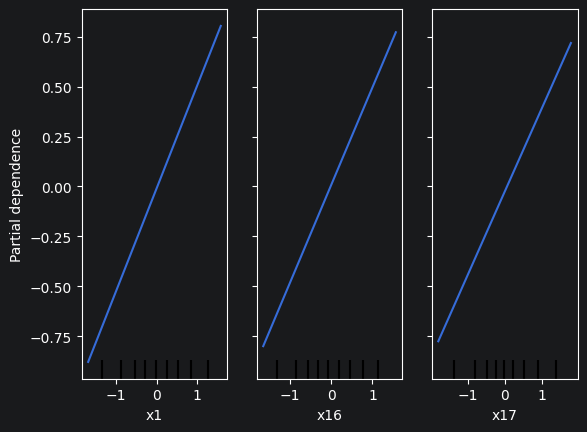

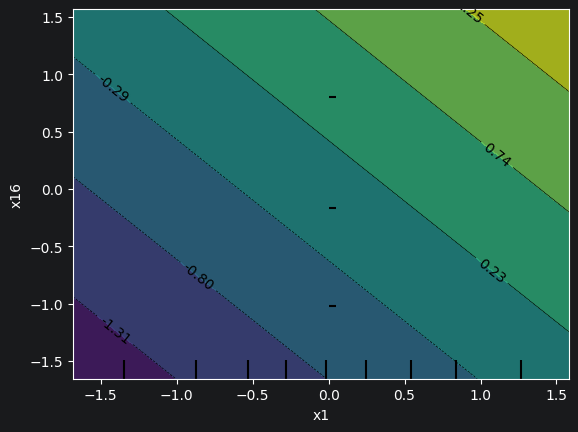

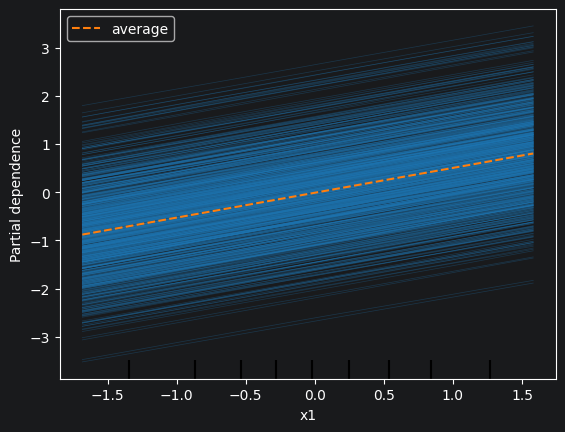

In [32]:
from sklearn.inspection import PartialDependenceDisplay

features = [1,16,17]
PartialDependenceDisplay.from_estimator(regressor, X_test_scaled, features)

features = [(1,16)]
PartialDependenceDisplay.from_estimator(regressor, X_test_scaled, features)

PartialDependenceDisplay.from_estimator(regressor, X_test_scaled, [1], kind='both')

# LIME

# Shapley